# Main Sudoku Pipeline

The main pipeline for identifying Sudoku. The image is gaussian blurred using a linear filter to remove noise, and converted to binary image using adaptive thresholding.

The contour of sudoku board is found and used to warp the image into a perfect 450x450 square using homography.

The perspective warped image is then divided into 81 cells and each cell is passed into one of the two ML models for digit recognition:
- CNN (Convolutional Neural Network)
- SVM (Support Vector Machines)

Run all cells to see the output of both ML models.

After all the digits are identified, a backtracking algorithm is used to solve the sudoku puzzle.

In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from skimage import filters
from skimage.io import imread
from skimage.feature import corner_peaks
from preprocessing import *
from solver import solve_sudoku, display_board, is_valid_sudoku

In [2]:
def display_image_grayscale(image, title="Image"):
    plt.imshow(image, cmap='gray', vmin=0, vmax=255)
    plt.title(title)
    plt.axis('off')
    plt.show()

def display_image_color(image, title="Image"):
    plt.imshow(image)
    plt.title(title)
    plt.axis('off')
    plt.show()

In [3]:
def extract_sudoku_cells(board):
    """
    Divides a perspective-corrected Sudoku board into 81 individual cells.
    Applies Gaussian blur and adaptive thresholding internally to determine
    which cells are empty. The raw (non-thresholded) cropped cell is returned
    alongside the empty flag for use by the digit classifier downstream.
    Args:
        board (numpy array): Grayscale board image, pre-processed using perspective
                             transform so that only the Sudoku grid is visible.
                             Expected to be a square image divisible by 9 (e.g. 450x450).
    Returns:
        list: 81 tuples of (cell_image, is_empty) in row-major order, where
              cell_image is a cropped grayscale cell with grid lines removed,
              and is_empty is a bool indicating whether the cell contains a digit.
    """
    N, M = board.shape

    # Blur and threshold the warped board to get clean binary cells for empty detection
    blurred_board = linear_filter(board, create_gaussian_kernel(9, 1.6), is_clipped=True)
    thresh = apply_adaptive_threshold(blurred_board, 11, 2, is_inverse=True)

    cells = []
    cell_h = N // 9
    cell_w = M // 9

    for i in range(9):   # Rows
        for j in range(9):  # Columns

            # Compute pixel boundaries for this cell
            y_start, y_end = i * cell_h, (i + 1) * cell_h
            x_start, x_end = j * cell_w, (j + 1) * cell_w

            # Slice the raw (non-thresholded) cell for the classifier
            cell = board[y_start:y_end, x_start:x_end]

            # Crop margin on all sides to exclude grid lines from the digit region
            margin_percent = 0.12
            margin_y = int(cell_h * margin_percent)
            margin_x = int(cell_w * margin_percent)
            cell_cropped = cell[margin_y:-margin_y, margin_x:-margin_x]

            # Use the thresholded cell (not the cropped one) for empty detection
            # since is_cell_empty applies its own internal margin crop
            isEmpty = is_cell_empty(thresh[y_start:y_end, x_start:x_end], threshold_percent=0.06, margin_percent=0.15)

            cells.append((cell_cropped, isEmpty))

    return cells  # 81 (cell_image, is_empty) tuples in row-major order

## Preprocessing and Perspective Transform

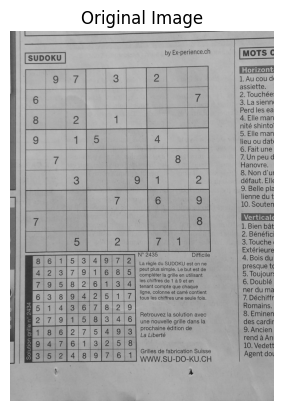

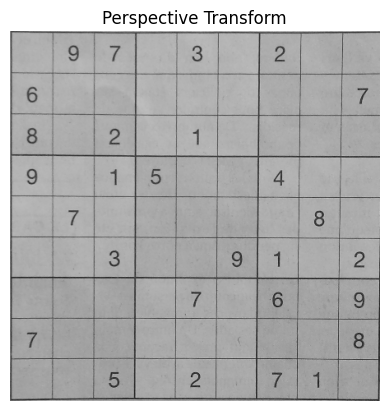

In [4]:
# Replace with image path
image_path = "data/sudoku_dataset/original/image1053.original.jpg" 

# Read the image in grayscale
img = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)
display_image_grayscale(img, "Original Image")
if img is None:
    raise ValueError("Image not found. Check the path.")

original = img.copy()

# Pre-process: Blur and Adaptive Thresholding
# Gaussian blur reduces high-frequency noise
gaussian_kernel = create_gaussian_kernel(9, 1.6)
blurred = linear_filter(img, gaussian_kernel, is_clipped=True)

# Thresholding
thresh = apply_adaptive_threshold(blurred, 11, 2, is_inverse=True)

# Find contours (I don't think we can build custom version)
contours, _ = cv2.findContours(thresh, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE) # Suzuki Abe algorithm

contours = sorted(contours, key=cv2.contourArea, reverse=True)

grid_contour = None
for contour in contours[:3]:
    contour = contour[:,0,:]
    perimeter = find_arc_length(contour, is_closed=True)
    epsilon = 0.02 * perimeter
    approx = approximate_polygon(contour, epsilon, is_closed=True)
    if len(approx) == 4:
        grid_contour = approx
        break

if grid_contour is None:
    raise ValueError("Could not find 4 corners of the Sudoku board. Try better lighting.")


# Perspective Transform (Flatten the board)
rect = order_points(grid_contour)

# Create a perfect square image to map the board to (450x450 is easily divisible by 9)
side_length = 450
dst = np.array([
    [0, 0],
    [side_length - 1, 0],
    [side_length - 1, side_length - 1],
    [0, side_length - 1]
], dtype="float32")

# Calculate the homography matrix and apply it
matrix = get_perspective_transform(rect, dst)

# added logic t pick and choose the warp function and which one to use overall
board_img = warp_perspective_inverse(original, matrix, (side_length, side_length))
display_image_grayscale(board_img, "Perspective Transform")


## CNN (Convolutional Neural Network)
Digit recognition using CNN model trained in DigitRecognitionCNN.ipynb

### Orientation Invariance
Applies prediction to get the softmax probability for the extracted sudoku cells at four different 90 degree orientations. The best model score is found and used to find the correct orientation.

In [5]:
from utils import normalize_cell
from cnn_model import load_digit_cnn, predict_digit

cnn_model, cnn_device = load_digit_cnn("models/digit_cnn.pth")

rotation_scores = {}
for angle in [0, 90, 180, 270]:
    rotated = rotate_board(board_img, angle)
    cells = extract_sudoku_cells(rotated)
    non_empty = [c[0] for c in cells if not c[1]]
    if len(non_empty) == 0:
        continue
    confidences = [
        predict_digit(cnn_model, normalize_cell(c), cnn_device)[1]
        for c in non_empty
    ]
    avg_confidence = np.mean(confidences)
    print(f"angle: {angle} degrees\t score: {avg_confidence:.4f}")
    rotation_scores[angle] = avg_confidence

rotation_scores = dict(sorted(rotation_scores.items(), key=lambda item: item[1], reverse=True))
print(rotation_scores)


angle: 0 degrees	 score: 0.9869
angle: 90 degrees	 score: 0.6572
angle: 180 degrees	 score: 0.7795
angle: 270 degrees	 score: 0.8111
{0: np.float64(0.9869346959250314), 270: np.float64(0.8110656759568623), 180: np.float64(0.7795488270265716), 90: np.float64(0.657236077955791)}


### Digit Recognition

Load the trained CNN model and classify each non-empty cell extracted above.


In [6]:
def recognize_digits_cnn(cells):
    board = []
    confidence_board = []
    for i in range(9):
        row = []
        confidence_row = []
        for j in range(9):
            cell_img, is_empty = cells[i * 9 + j]
            if is_empty:
                row.append(".")
                confidence_row.append(None)
            else:
                cell_normalized = normalize_cell(cell_img)
                digit, confidence = predict_digit(cnn_model, cell_normalized, cnn_device)
                row.append(str(digit))
                confidence_row.append(confidence)
        board.append(row)
        confidence_board.append(confidence_row)
    return board, confidence_board

Checking 0 degrees with score: 0.9869
0 degrees is valid


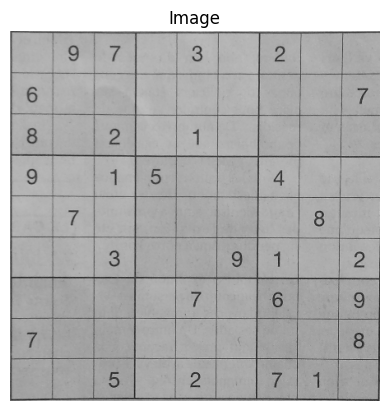

Unsolved board:
. 9 7 | . 3 . | 2 . . 
6 . . | . . . | . . 7 
8 . 2 | . 1 . | . . . 
------+-------+------
9 . 1 | 5 . . | 4 . . 
. 7 . | . . . | . 8 . 
. . 3 | . . 9 | 1 . 2 
------+-------+------
. . . | . 7 . | 6 . 9 
7 . . | . . . | . . 8 
. . 5 | . 2 . | 7 1 . 

Solved board:
5 9 7 | 8 3 6 | 2 4 1 
6 1 4 | 2 9 5 | 8 3 7 
8 3 2 | 4 1 7 | 5 9 6 
------+-------+------
9 8 1 | 5 6 2 | 4 7 3 
2 7 6 | 1 4 3 | 9 8 5 
4 5 3 | 7 8 9 | 1 6 2 
------+-------+------
1 2 8 | 3 7 4 | 6 5 9 
7 4 9 | 6 5 1 | 3 2 8 
3 6 5 | 9 2 8 | 7 1 4 


In [7]:
board = None
for angle, score in rotation_scores.items():
    final_board_img = rotate_board(board_img, angle)
    final_cells = extract_sudoku_cells(final_board_img)
    board, confidence_board = recognize_digits_cnn(final_cells)
    print(f"Checking {angle} degrees with score: {score:.4f}")
    if is_valid_sudoku(board):
        print(f"{angle} degrees is valid")
        break

if not is_valid_sudoku(board):
    raise ValueError("Invalid board — digit recognition may have errors or the board is impossible to solve.")

display_image_grayscale(final_board_img)
print("Unsolved board:")
display_board(board)
solve_sudoku(board)
print()
print("Solved board:")
display_board(board)


## SVM (Support Vector Machines)
Digit recognition using SVM model trained in DigitRecognitionSVM.ipynb

### Orientation Invariance
Applies decision function to the extracted sudoku cells at four different 90 degree orientations. The best model score is found and used to find the correct orientation.

In [8]:
import joblib
from utils import normalize_cell, extract_features
model = joblib.load("models/digit_svm.pkl")
rotation_scores = {}
for angle in [0, 90, 180, 270]:
    rotated = rotate_board(board_img, angle)
    cells = extract_sudoku_cells(rotated)
    non_empty = [c[0] for c in cells if not c[1]]
    if len(non_empty) == 0:
        continue
    confidences = [model.decision_function(extract_features([normalize_cell(c)]))[0].max() for c in non_empty]
    avg_confidence = np.mean(confidences)
    rotation_scores[angle] = avg_confidence
        
rotation_scores = dict(sorted(rotation_scores.items(), key=lambda item: item[1], reverse=True))

### Digit Recognition

Load the trained SVM model and classify each non-empty cell extracted above.

In [9]:
def recognize_digits_svm(cells):
    board = []
    for i in range(9):
        row = []
        for j in range(9):
            cell_img, is_empty = cells[i * 9 + j]
            if is_empty:
                row.append(".")
            else:
                cell_normalized = normalize_cell(cell_img)
                features = extract_features([cell_normalized])
                digit = model.predict(features)[0]
                row.append(str(digit))
        board.append(row)
    return board

0 degrees is valid


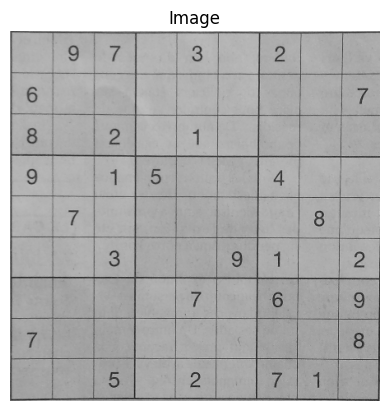

Unsolved board:
. 9 7 | . 3 . | 2 . . 
6 . . | . . . | . . 7 
8 . 2 | . 1 . | . . . 
------+-------+------
9 . 1 | 5 . . | 4 . . 
. 7 . | . . . | . 8 . 
. . 3 | . . 9 | 1 . 2 
------+-------+------
. . . | . 7 . | 6 . 9 
7 . . | . . . | . . 8 
. . 5 | . 2 . | 7 1 . 

Solved board:
5 9 7 | 8 3 6 | 2 4 1 
6 1 4 | 2 9 5 | 8 3 7 
8 3 2 | 4 1 7 | 5 9 6 
------+-------+------
9 8 1 | 5 6 2 | 4 7 3 
2 7 6 | 1 4 3 | 9 8 5 
4 5 3 | 7 8 9 | 1 6 2 
------+-------+------
1 2 8 | 3 7 4 | 6 5 9 
7 4 9 | 6 5 1 | 3 2 8 
3 6 5 | 9 2 8 | 7 1 4 


In [10]:
board = None
for angle, score in rotation_scores.items():
    final_board_img = rotate_board(board_img, angle)
    final_cells = extract_sudoku_cells(final_board_img)
    board = recognize_digits_svm(final_cells)
    if is_valid_sudoku(board):
        print(f"{angle} degrees is valid")
        break

if board is None or not is_valid_sudoku(board):
    raise ValueError("Invalid board — digit recognition may have errors or the board is impossible to solve.")

display_image_grayscale(final_board_img)
print("Unsolved board:")
display_board(board)
solve_sudoku(board)
print()
print("Solved board:")
display_board(board)